# About Data

In [1]:
import pandas as pd

In [2]:
train_data = pd.read_csv('data/dataset.csv')
test_data = pd.read_csv('data/test.csv')

In [3]:
print("Train Data:",train_data.shape[0])
print("Train Data labels distribution:\n",train_data['label'].value_counts())
print("Train Data max length of prompts:",train_data['prompt'].apply(lambda x: len(x)).max())
print("Test Data:",test_data.shape[0])
print("Test Data max length of prompts:",test_data['prompt'].apply(lambda x: len(x)).max())

Train Data: 689
Train Data labels distribution:
 label
1.0    483
0.0    206
Name: count, dtype: int64
Train Data max length of prompts: 3278
Test Data: 100
Test Data max length of prompts: 3645


In [ ]:
import matplotlib.pyplot as plt

train_data['prompt_len']   = train_data['prompt'].str.len()
train_data['response_len'] = train_data['response'].str.len()
train_data['total_len']    = train_data['prompt_len'] + train_data['response_len']

# Rough token estimate: ~4 chars per token (works well for English/ChatML)
train_data['total_tokens_est'] = train_data['total_len'] / 4

print(train_data[['prompt_len', 'response_len', 'total_len', 'total_tokens_est']].describe().round(1))


       prompt_len  response_len  total_len  total_tokens_est
count       689.0         689.0      689.0             689.0
mean       1338.4         684.4     2022.7             505.7
std         326.5         728.1      837.6             209.4
min         713.0          16.0      789.0             197.2
25%        1114.0         145.0     1430.0             357.5
50%        1280.0         373.0     1764.0             441.0
75%        1484.0         923.0     2398.0             599.5
max        3278.0        2840.0     5744.0            1436.0


## Truncation risk (MAX_LENGTH = 512 tokens)

The model can see only first 512 tokens. If prompt + response longer — answer cuts.  
Need to know: for how many samples answer fits border?

In [6]:
MAX_LENGTH = 512

truncated = train_data['total_tokens_est'] > MAX_LENGTH
n_truncated = truncated.sum()
print(f"Samples with truncation: {n_truncated} / {len(train_data)}  ({100*n_truncated/len(train_data):.1f}%)")
print()

df_trunc = train_data[truncated].copy()
df_trunc['prompt_tokens_est']    = df_trunc['prompt_len'] / 4
df_trunc['response_tokens_est']  = df_trunc['response_len'] / 4
df_trunc['response_tokens_seen'] = (MAX_LENGTH - df_trunc['prompt_tokens_est']).clip(lower=0)
df_trunc['response_frac_seen']   = df_trunc['response_tokens_seen'] / df_trunc['response_tokens_est']

print("Part of truncatedsamples which still in window:")
print(df_trunc['response_frac_seen'].describe().round(3))
print()

# Samples with <10% answer in window 
blind = (df_trunc['response_frac_seen'] < 0.1).sum()
print(f"Samples where less than 10% of the answer is visible: {blind}")

# Class balance truncated
print("\n Class balance truncated:")
print(train_data[truncated]['label'].value_counts())


Samples with truncation: 234 / 689  (34.0%)

Part of truncatedsamples which still in window:
count    234.000
mean       0.442
std        0.288
min        0.000
25%        0.227
50%        0.398
75%        0.686
max        0.991
Name: response_frac_seen, dtype: float64

Samples where less than 10% of the answer is visible: 33

 Class balance truncated:
label
1.0    197
0.0     37
Name: count, dtype: int64


## Leght of answer by class

H0: halucinated answers shorter or longer than normal ones.

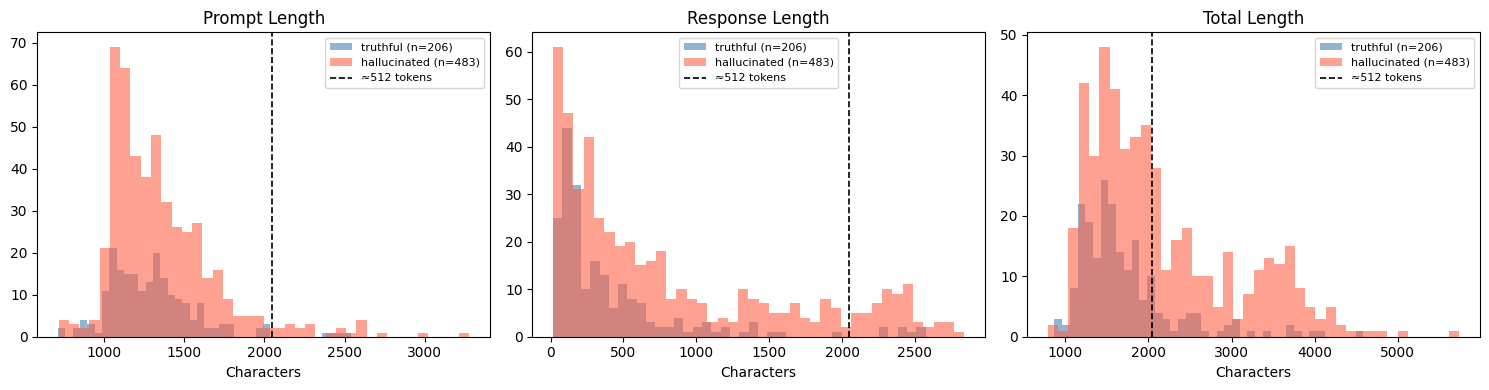

Median answer length by class:
label
0.0    222.5
1.0    487.0
Name: response_len, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title in zip(axes,
                           ['prompt_len', 'response_len', 'total_len'],
                           ['Prompt Length', 'Response Length', 'Total Length']):
    for label, color, name in [(0, 'steelblue', 'truthful'), (1, 'tomato', 'hallucinated')]:
        subset = train_data[train_data['label'] == label][col]
        ax.hist(subset, bins=40, alpha=0.6, color=color, label=f'{name} (n={len(subset)})')
    ax.axvline(512 * 4, color='black', linestyle='--', linewidth=1.2, label='≈512 tokens')
    ax.set_title(title)
    ax.set_xlabel('Characters')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Median answer length by class:")
print(train_data.groupby('label')['response_len'].median())


## Duplicated answers

If we have doupels we need to know

In [9]:
prompt_counts = train_data['prompt'].value_counts()
duplicate_prompts = prompt_counts[prompt_counts > 1]

print(f"Unique prompts: {len(prompt_counts)} out of {len(train_data)} samples")
print(f"Prompts appearing >1 time: {len(duplicate_prompts)}")

if len(duplicate_prompts) > 0:
    print("\nExample duplicates with different labels:")
    for prompt in duplicate_prompts.index[:3]:
        subset = train_data[train_data['prompt'] == prompt][['label', 'response_len']]
        print(f"\n--- prompt (first 80 characters): {prompt[:80]!r}")
        print(subset.to_string(index=False))
else:
    print("No duplicates — each prompt is unique.")


Unique prompts: 689 out of 689 samples
Prompts appearing >1 time: 0
No duplicates — each prompt is unique.
